In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.shape

(569, 33)

# Drop columns

In [ ]:
df.drop(columns=['Unnamed: 32', 'id'], inplace=True)

In [ ]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Train test split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=.2,random_state=42)

# Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Encoder


In [ ]:
labelencoder = LabelEncoder()
y_train = labelencoder.fit_transform(y_train)
y_test = labelencoder.transform(y_test)

In [ ]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [ ]:
X_train

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]])

In [ ]:
y_train

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,

In [ ]:
X_train.shape[1]

30

In [ ]:
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train).float().unsqueeze(1)
y_test_tensor = torch.from_numpy(y_test).float().unsqueeze(1)

In [ ]:
import torch.nn as nn

In [ ]:
class SimpleNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.linear = nn.Linear(num_features,1)

    self.sigmoid= nn.Sigmoid()

  def forward(self,features):
    out = self.linear(features)
    out = self.sigmoid(out)

    return out

In [ ]:
X_train_tensor.shape[1]

30

In [ ]:
#parameters
learning_rate = 0.1
num_epochs = 35

In [ ]:
loss_function =nn.BCELoss()

In [ ]:
type(loss_function)

torch.nn.modules.loss.BCELoss

In [ ]:
model.linear.weight.dtype

torch.float32

In [ ]:
model.parameters()

<generator object Module.parameters at 0x7d922bc89d20>

In [ ]:
for param in model.parameters():
    print(type(param), param.size())

<class 'torch.nn.parameter.Parameter'> torch.Size([1, 30])
<class 'torch.nn.parameter.Parameter'> torch.Size([1])


# Pipeline

Epoch 1, Loss =0.8766170740127563

Epoch 2, Loss =0.6119477152824402

Epoch 3, Loss =0.47965842485427856

Epoch 4, Loss =0.4067111909389496

Epoch 5, Loss =0.3603908121585846

Epoch 6, Loss =0.32798266410827637

Epoch 7, Loss =0.30376940965652466

Epoch 8, Loss =0.2848179042339325

Epoch 9, Loss =0.2694665193557739

Epoch 10, Loss =0.25670090317726135

Epoch 11, Loss =0.24586468935012817

Epoch 12, Loss =0.23651297390460968

Epoch 13, Loss =0.2283327877521515

Epoch 14, Loss =0.22109664976596832

Epoch 15, Loss =0.214634969830513

Epoch 16, Loss =0.208818256855011

Epoch 17, Loss =0.20354579389095306

Epoch 18, Loss =0.19873768091201782

Epoch 19, Loss =0.1943298727273941

Epoch 20, Loss =0.19026999175548553

Epoch 21, Loss =0.18651488423347473

Epoch 22, Loss =0.1830286830663681

Epoch 23, Loss =0.17978104948997498

Epoch 24, Loss =0.17674632370471954

Epoch 25, Loss =0.17390254139900208

Epoch 26, Loss =0.17123068869113922

Epoch 27, Loss =0.16871441900730133

Epoch 28, Loss =0.16633

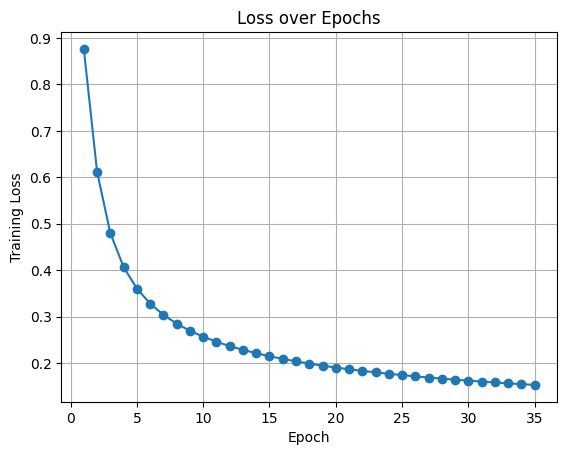

In [ ]:
#Create model
model = SimpleNN(X_train_tensor.shape[1])

#losses
losses = []

#Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

for epoch in range(num_epochs):
  #forward pass
  y_pred = model(X_train_tensor)

  #Loss calculate
  loss = loss_function(y_pred, y_train_tensor.reshape(-1,1))

  #Zero grad
  optimizer.zero_grad()

  #backward pass
  loss.backward()


  #Parameter update
  optimizer.step()

  losses.append(loss.item())

  # with torch.no_grad():
  #   model.linear.weight -= learning_rate * model.linear.weight.grad
  #   model.linear.bias -= learning_rate * model.linear.bias.grad

  # zero gradient
  # model.linear.weight.grad.zero_()
  # model.linear.bias.grad.zero_()

  print(f"Epoch {epoch+1}, Loss ={loss.item()}\n")

plt.plot(range(1, num_epochs+1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Loss over Epochs')
plt.grid(True)
plt.show()

# Accuracy

Accuracy: 0.8684210777282715



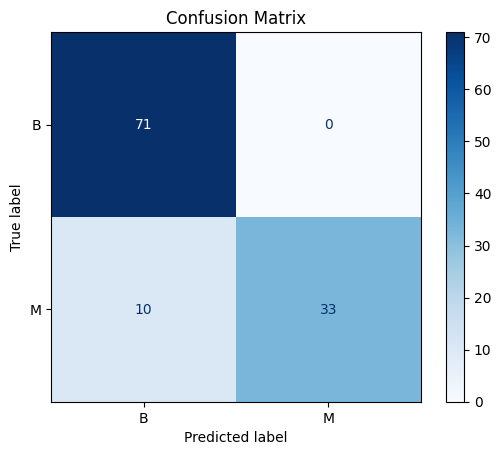

In [ ]:

with torch.no_grad():
  y_pred = model.forward(X_test_tensor)
  y_pred = (y_pred > 0.9).float()

  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f"Accuracy: {accuracy}\n")

cm = confusion_matrix(y_test_tensor, y_pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=labelencoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Summary

In [ ]:
!pip install torchinfo


In [ ]:
X_train_tensor.shape

torch.Size([455, 30])

In [ ]:
from torchinfo import summary


summary(model, input_size=(455,30))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleNN                                 [455, 1]                  --
├─Linear: 1-1                            [455, 1]                  31
├─Sigmoid: 1-2                           [455, 1]                  --
Total params: 31
Trainable params: 31
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.05
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.06